# Comparison Between Likely-Memorized Questions and TAU Exam Questions

## Setup

### Environment Setup

In [1]:
# import sys
# import subprocess

# # packages = open("requirements.txt").read().splitlines()
# packages = open("requirements2.txt").read().splitlines()
# print(f"🔄 Synchronizing environment dependencies: {packages}...")
# subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade"] + packages)
# print("✅ Synchronization complete. Packages are now compatible.")

In [2]:
from openai import OpenAI
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.metrics.pairwise import cosine_distances
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
from xgboost import XGBClassifier
from pulearn import ElkanotoPuClassifier
from sklearn.cluster import KMeans
from scipy.stats import multivariate_normal
from mpl_toolkits.mplot3d import Axes3D
import uuid
import json
from pathlib import Path
from utils import BASE_DIR, INPUT_DIR, PROMPTS_DIR, OUTPUTS_DIR, API_INPUT_DIR, API_OUTPUT_DIR, API_JOBS_DIR, create_prompt, create_batch_input_file, \
    send_input_to_api, wait_for_batch_completion, retrieve_api_output, output_jsonl_to_dataframe, run_whole_batch_process

API_KEY = os.getenv("OPENAI_API_KEY_UNIVERSITY")
client = OpenAI(api_key=API_KEY)

### Helper Functions

In [3]:
def load_df(file_name: str, file_dir: Path=INPUT_DIR) -> pd.DataFrame:
    file_path = file_dir / file_name
    if file_path.suffix == ".pkl":
        return pd.read_pickle(file_path)
    elif file_path.suffix == ".xlsx":
        return pd.read_excel(file_path)
    elif file_path.suffix == ".csv":
        return pd.read_csv(file_path)
    else:
        raise ValueError("Unsupported file format")
    
def merge_dfs(df1: pd.DataFrame, df2: pd.DataFrame, on_left: str="id", on_right="custom_id", how: str="left", df1_columns=None, df2_columns=None) -> pd.DataFrame:
    if df1_columns is not None:
        df1 = df1[df1_columns + [on_left]]
    if df2_columns is not None:
        df2 = df2[df2_columns + [on_right]]
    merged_df = pd.merge(df1, df2, left_on=on_left, right_on=on_right, how=how, suffixes=('_left', '_right'))
    return merged_df

In [4]:
df_exam_questions = load_df("exams_df_processed.xlsx")
df_likely_memorized = load_df("likely_memorized_df_processed.xlsx")

print("Exams df columns:", df_exam_questions.columns)
print("Likely memorized df columns:", df_likely_memorized.columns)

Exams df columns: Index(['id', 'year', 'semester', 'moed', 'question', 'section', 'points',
       'question_hebrew', 'solution_hebrew', 'avg_score', 'std_score',
       'max_score', 'avg_score_norm', 'std_score_norm', 'question_english',
       'solution_english', 'subject_labels', 'task_type_labels', 'custom_id',
       'reasoning_tokens_mean', 'reasoning_tokens_std', 'reasoning_tokens_min',
       'reasoning_tokens_max', 'reasoning_tokens_median',
       'log_reasoning_tokens_mean', 'log_reasoning_tokens_std',
       'log_reasoning_tokens_min', 'log_reasoning_tokens_max',
       'log_reasoning_tokens_median', 'grade_mean', 'grade_std', 'grade_min',
       'grade_max', 'grade_median', 'reasoning_tokens_mean_normalized',
       'reasoning_tokens_std_normalized', 'reasoning_tokens_min_normalized',
       'reasoning_tokens_max_normalized', 'reasoning_tokens_median_normalized',
       'log_reasoning_tokens_mean_normalized',
       'log_reasoning_tokens_std_normalized',
       'log_reason

## Datasets Comparison

In [5]:
# perform an unpaired t-test to test the following hypotheses (likely memorized df vs non-likely memorized questions in exams df):
# H1: grade std of likely memorized questions is significantly lower than grade std of non-likely memorized questions
# H2: reasoning tokens mean of likely memorized questions is significantly lower than reasoning tokens mean of non-likely memorized questions
# H3: average answer distance of likely memorized questions is significantly lower than average answer distance of non-likely memorized questions
from scipy.stats import ttest_ind

grade_std_ttest = ttest_ind(
    df_likely_memorized['grade_std'],
    df_exam_questions['grade_std'],
    equal_var=False,
    alternative='less'
)

grade_mean_ttest = ttest_ind(
    df_exam_questions['grade_mean'],
    df_likely_memorized['grade_mean'],
    equal_var=False,
    alternative='less'
)

reasoning_tokens_mean_ttest = ttest_ind(
    df_likely_memorized['reasoning_tokens_mean'],
    df_exam_questions['reasoning_tokens_mean'],
    equal_var=False,
    alternative='less'
)

reasoning_tokens_std_ttest = ttest_ind(
    df_likely_memorized['reasoning_tokens_std'],
    df_exam_questions['reasoning_tokens_std'],
    equal_var=False,
    alternative='less'
)

avg_answer_distance_ttest = ttest_ind(
    df_likely_memorized['avg_answer_distance'],
    df_exam_questions['avg_answer_distance'],
    equal_var=False,
    alternative='less'
)

print("Grade mean t-test: ,statistic={:.4f}, p-value={:.4f}, significant={}".format(grade_mean_ttest.statistic, grade_mean_ttest.pvalue, grade_mean_ttest.pvalue < 0.05))
print(f"Grade std t-test: statistic={grade_std_ttest.statistic:.4f}, p-value={grade_std_ttest.pvalue:.4f}, significant={grade_std_ttest.pvalue < 0.05}")
print(f"Average answer distance t-test: statistic={avg_answer_distance_ttest.statistic:.4f}, p-value={avg_answer_distance_ttest.pvalue:.4f}, significant={avg_answer_distance_ttest.pvalue < 0.05}")
print(f"Reasoning tokens mean t-test: statistic={reasoning_tokens_mean_ttest.statistic:.4f}, p-value={reasoning_tokens_mean_ttest.pvalue:.4f}, significant={reasoning_tokens_mean_ttest.pvalue < 0.05}")
print(f"Reasoning tokens std t-test: statistic={reasoning_tokens_std_ttest.statistic:.4f}, p-value={reasoning_tokens_std_ttest.pvalue:.4f}, significant={reasoning_tokens_std_ttest.pvalue < 0.05}")

Grade mean t-test: ,statistic=-7.3436, p-value=0.0000, significant=True
Grade std t-test: statistic=-9.2125, p-value=0.0000, significant=True
Average answer distance t-test: statistic=-10.2349, p-value=0.0000, significant=True
Reasoning tokens mean t-test: statistic=-1.2162, p-value=0.1131, significant=False
Reasoning tokens std t-test: statistic=-4.8079, p-value=0.0000, significant=True


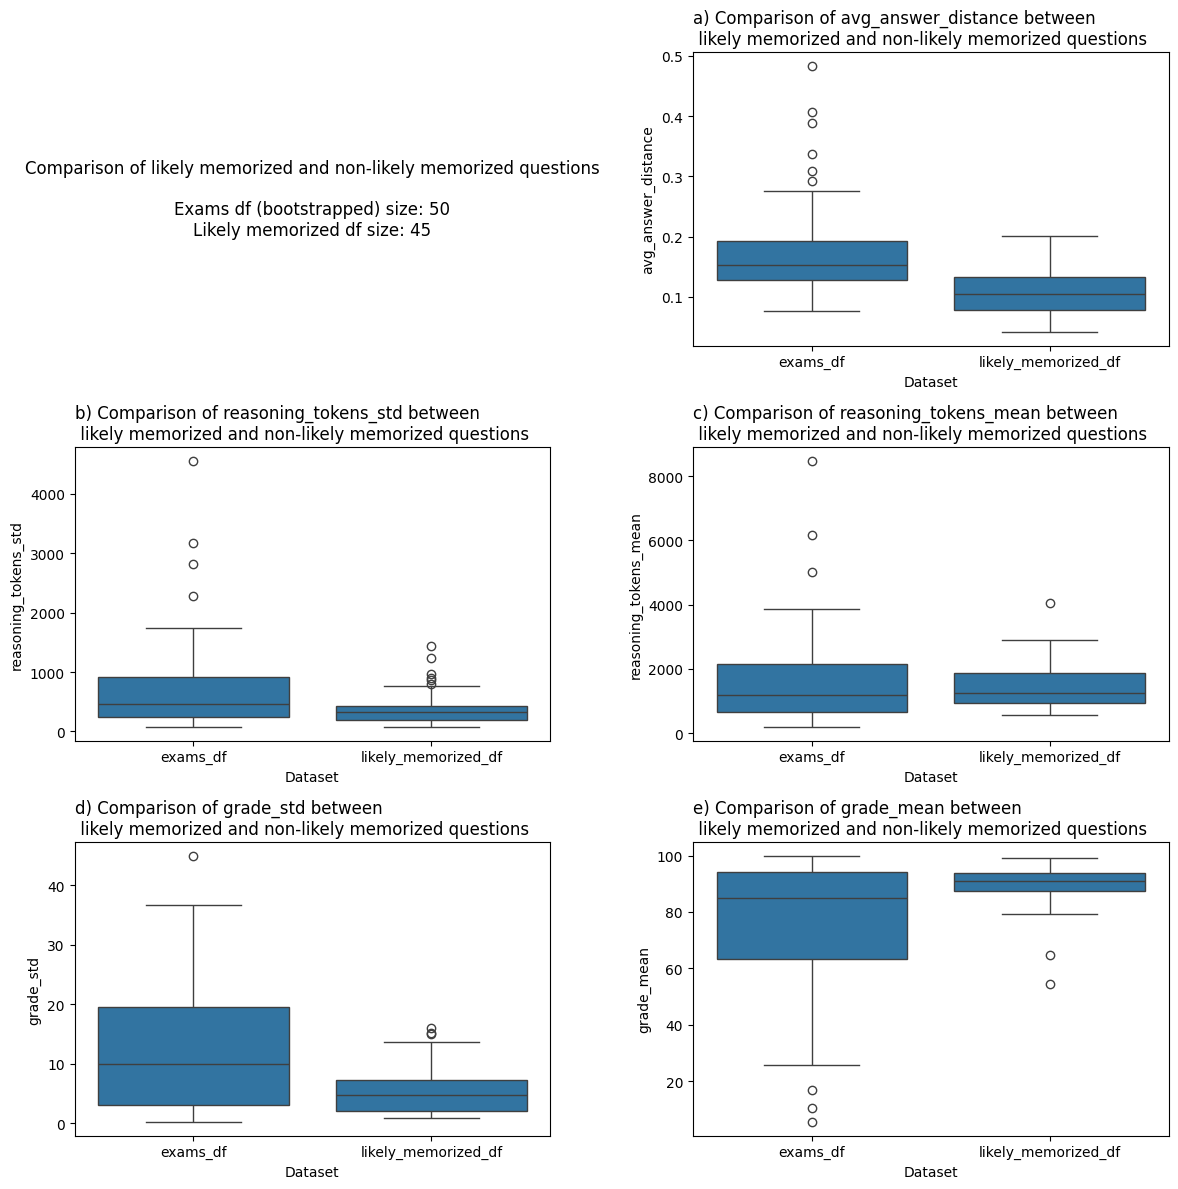

In [46]:
# # create comparative boxplots for each of the following columns: 'avg_answer_distance', 'grade_std', 'grade_mean'. each boxplot should compare the distribution of the column for likely memorized questions vs non-likely memorized questions
# # df_exam_questions and df_likely_memorized are unpaired datasets
# df_exam_questions['dataset'] = 'exams_df'
# df_likely_memorized['dataset'] = 'likely_memorized_df'
# combined_df = pd.concat([df_exam_questions, df_likely_memorized], ignore_index=True)

# # for exams_df source, for each metric column, bootstrap 50 samples 5 times and average the results to get a more robust estimate of the distribution, then create boxplots for each metric column comparing likely memorized and non-likely memorized questions


# # arrange all plots in a 3x2 grid
# fig, axes = plt.subplots(3, 2, figsize=(12, 12))
# num_to_letter = {1:'a)', 2:'b)', 3:'c)', 4:'d)', 5:'e)'}
# columns = ['', 'avg_answer_distance', 'reasoning_tokens_std', 'reasoning_tokens_mean', 'grade_std', 'grade_mean']
# for i, column in enumerate(columns):
#     if column == '':
#         # instead of subplot in position 0, show a textbox with a headline inside the subplot and remind the size of each dataset
#         axes[i//2, i%2].text(0.5, 0.5, f"Comparison of likely memorized and non-likely memorized questions\n\nExams df size: {len(df_exam_questions)}\nLikely memorized df size: {len(df_likely_memorized)}", ha='center', va='center', fontsize=12)
#         axes[i//2, i%2].set_axis_off()    
#     else:
#         sns.boxplot(x='dataset', y=column, data=combined_df, ax=axes[i//2, i%2])
#         # set title to the left side of the plot 
#         axes[i//2, i%2].set_title(f'{num_to_letter.get(i, "")} Comparison of {column} between \n likely memorized and non-likely memorized questions', loc='left')
#         axes[i//2, i%2].set_xlabel('Dataset')
#         axes[i//2, i%2].set_ylabel(column)
# plt.tight_layout()
# plt.show()

# Assuming df_exam_questions and df_likely_memorized are already defined in your environment
metrics = ['avg_answer_distance', 'reasoning_tokens_std', 'reasoning_tokens_mean', 'grade_std', 'grade_mean']

# --- Fulfill middle instruction: Bootstrap exams_df ---
bootstrapped_data = {}

for col in metrics:
    if col in df_exam_questions.columns:
        # Bootstrap 50 samples 5 times
        samples = [df_exam_questions[col].sample(n=50, replace=True, random_state=i).sort_values().values for i in range(5)]
        # Average the 5 arrays of 50 samples to get a robust estimate of the distribution
        bootstrapped_data[col] = np.mean(samples, axis=0)

# Create a new dataframe with the bootstrapped distributions
df_exams_bootstrapped = pd.DataFrame(bootstrapped_data)
df_exams_bootstrapped['dataset'] = 'exams_df'

# df_likely_memorized dataset assignment
df_likely_memorized = df_likely_memorized.copy()
df_likely_memorized['dataset'] = 'likely_memorized_df'

# Concatenate the bootstrapped exams data with the likely memorized data
combined_df = pd.concat([df_exams_bootstrapped, df_likely_memorized], ignore_index=True)

# --- Plotting ---
# arrange all plots in a 3x2 grid
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
num_to_letter = {1: 'a)', 2: 'b)', 3: 'c)', 4: 'd)', 5: 'e)'}
columns = ['', 'avg_answer_distance', 'reasoning_tokens_std', 'reasoning_tokens_mean', 'grade_std', 'grade_mean']

for i, column in enumerate(columns):
    row_idx = i // 2
    col_idx = i % 2
    
    if column == '':
        # instead of subplot in position 0, show a textbox with a headline inside the subplot and remind the size of each dataset
        axes[row_idx, col_idx].text(
            0.5, 0.5, 
            f"Comparison of likely memorized and non-likely memorized questions\n\n"
            f"Exams df (bootstrapped) size: {len(df_exams_bootstrapped)}\n"
            f"Likely memorized df size: {len(df_likely_memorized)}", 
            ha='center', va='center', fontsize=12
        )
        axes[row_idx, col_idx].set_axis_off()    
    else:
        # Check if column exists in combined_df before plotting to avoid KeyError
        if column in combined_df.columns:
            sns.boxplot(x='dataset', y=column, data=combined_df, ax=axes[row_idx, col_idx])
            # set title to the left side of the plot 
            axes[row_idx, col_idx].set_title(
                f'{num_to_letter.get(i, "")} Comparison of {column} between \n likely memorized and non-likely memorized questions', 
                loc='left'
            )
            axes[row_idx, col_idx].set_xlabel('Dataset')
            axes[row_idx, col_idx].set_ylabel(column)
        else:
            axes[row_idx, col_idx].text(0.5, 0.5, f"{column} not found in data", ha='center', va='center')
            axes[row_idx, col_idx].set_axis_off()

plt.tight_layout()
plt.show()

df_exam_questions['dataset'] = 'exams_df'
combined_df = pd.concat([df_exam_questions, df_likely_memorized], ignore_index=True)

## Measured Columns Clustering

Optimal number of clusters for Likely Memorized Questions: 2 with silhouette score: 0.3979


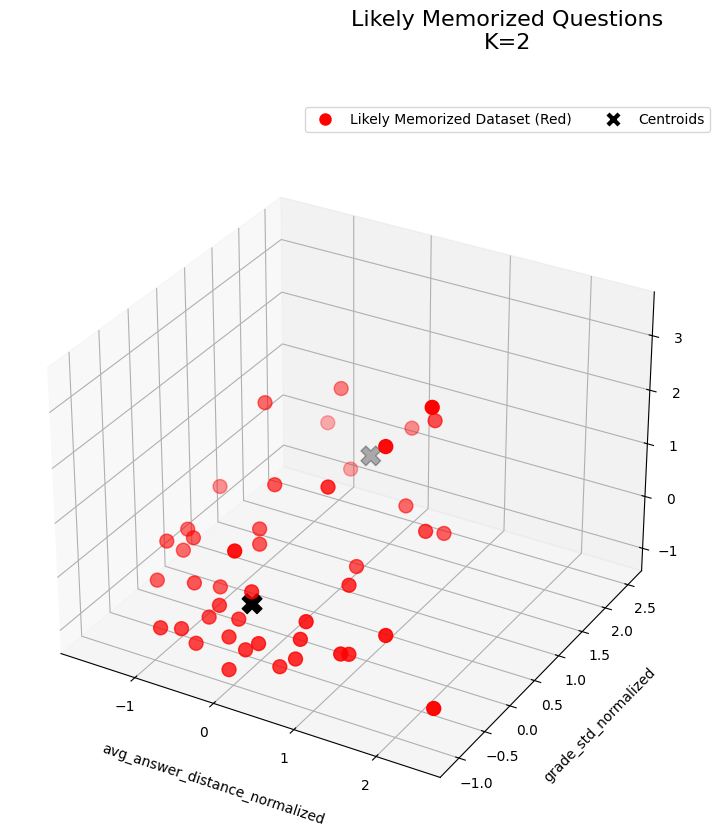

Cluster centers for Likely Memorized Questions:
Cluster 0: [-0.11783179 -0.47514891 -0.44088851]
Cluster 1: [0.29004747 1.16959732 1.08526402]
Optimal number of clusters for Exam Questions: 3 with silhouette score: 0.4627


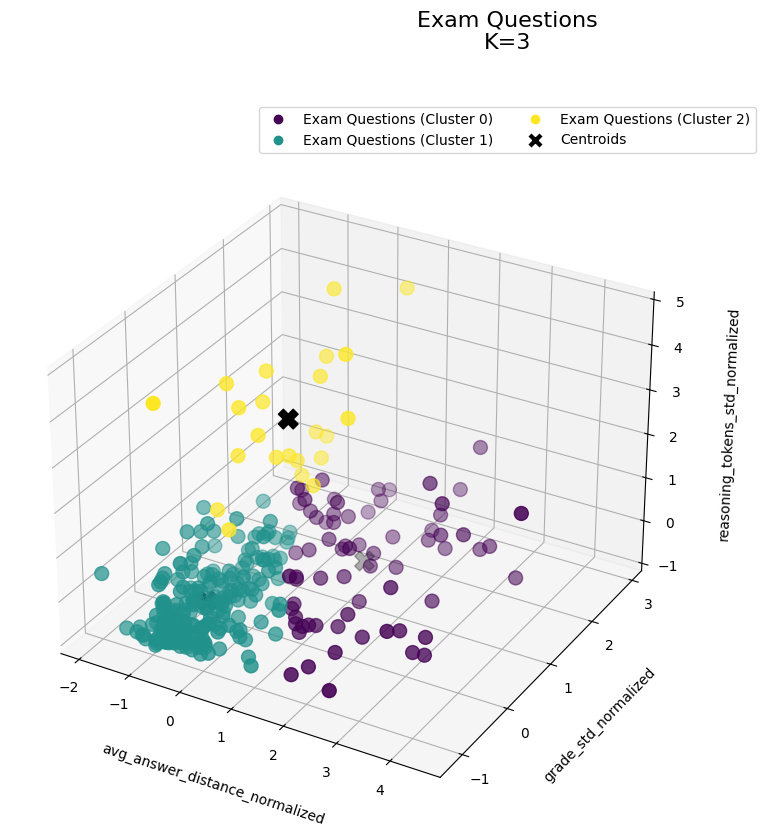

Cluster centers for Exam Questions:
Cluster 0: [ 1.2953835   1.03439807 -0.14175079]
Cluster 1: [-0.4441396  -0.44835825 -0.27100745]
Cluster 2: [-0.00314641  0.82857474  2.83513366]
Optimal number of clusters for Combined Questions: 2 with silhouette score: 0.4889


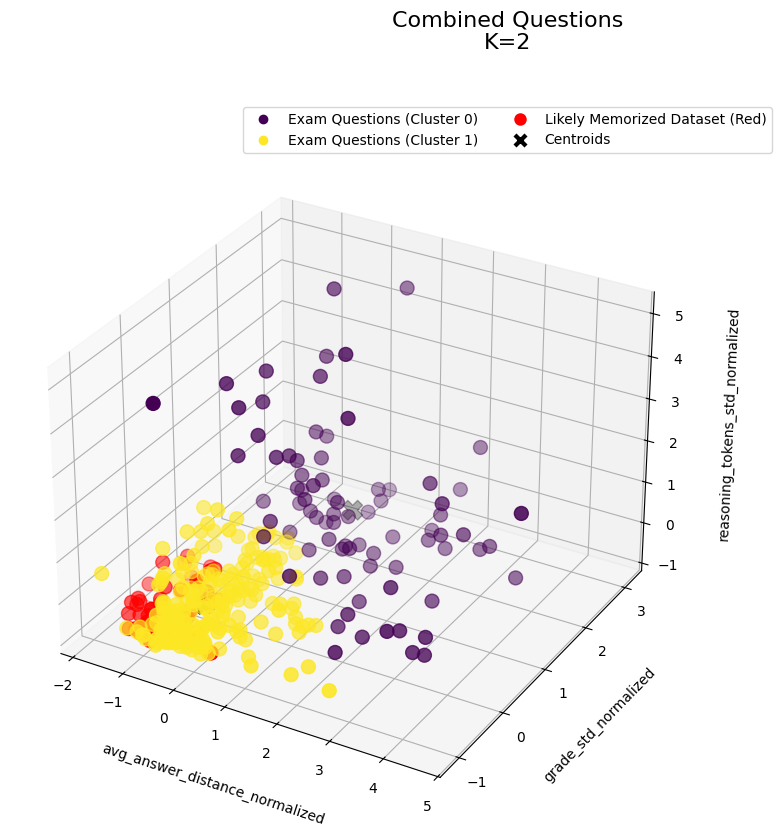

Cluster centers for Combined Questions:
Cluster 0: [1.05078091 1.32049356 0.85398712]
Cluster 1: [-0.32610442 -0.40980835 -0.26503049]
Cluster counts for likely memorized questions:


cluster
0    32
1    13
Name: count, dtype: int64

source,gpt,michal and amir
cluster,,
0,21,11
1,12,1



Cluster counts for exam questions:


cluster
1    204
0     70
2     23
Name: count, dtype: int64


Cluster counts for combined questions:


original_cluster
1    217
0    102
2     23
Name: count, dtype: int64


Cluster vs Original Cluster counts for combined questions:


original_cluster              0    1   2
cluster dataset                         
0       exams_df             56    4  21
1       exams_df             14  200   2
        likely_memorized_df  32   13   0

In [ ]:
# apply k-means in 2 figures: one for likely memorized questions and one for exams questions, using the following features: 'avg_answer_distance', 'grade_std', 'reasoning_tokens_std'. 
# color each cluster differently and display the cluster centers.
# the figures should be 3-D scatter plots with avg_answer_distance on the x-axis, grade_std on the y-axis, and reasoning_tokens_std on the z-axis.
# apply silhouette analysis to determine the optimal number of clusters and print the silhouette score for the chosen number of clusters.
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.spatial import ConvexHull

def plot_kmeans_clusters(df, features, dataset_name):
    X = df[features].dropna()
    silhouette_scores = []
    K_range = range(2, 10)
    for K in K_range:
        kmeans = KMeans(n_clusters=K, random_state=42)
        cluster_labels = kmeans.fit_predict(X)
        silhouette_avg = silhouette_score(X, cluster_labels)
        silhouette_scores.append(silhouette_avg)
    
    optimal_K = K_range[np.argmax(silhouette_scores)]
    print(f"Optimal number of clusters for {dataset_name}: {optimal_K} with silhouette score: {max(silhouette_scores):.4f}")
    
    kmeans_optimal = KMeans(n_clusters=optimal_K, random_state=42)
    df['cluster'] = kmeans_optimal.fit_predict(X)
    
    # 1. MASSIVE WIDESCREEN CANVAS
    fig = plt.figure(figsize=(16, 9))
    
    # 2. FORCEFUL LAYOUT: [left, bottom, width, height] as percentages of the canvas
    # This locks the 3D plot to 70% width, leaving a massive empty right margin.
    ax = fig.add_axes([0.05, 0.05, 0.70, 0.75], projection='3d')
    
    source_col = 'dataset' if 'dataset' in df.columns else 'source'
    exams_mask = df[source_col] == 'exams_df'
    non_exams_mask = df[source_col] != 'exams_df'
    
    scatter_exams = None
    if exams_mask.any():
        scatter_exams = ax.scatter(df.loc[exams_mask, features[0]], 
                                   df.loc[exams_mask, features[1]], 
                                   df.loc[exams_mask, features[2]], 
                                   c=df.loc[exams_mask, 'cluster'], 
                                   cmap='viridis', s=100)
    
    if non_exams_mask.any():
        ax.scatter(df.loc[non_exams_mask, features[0]], 
                   df.loc[non_exams_mask, features[1]], 
                   df.loc[non_exams_mask, features[2]], 
                   c='red', s=100)
        
    centers = kmeans_optimal.cluster_centers_
    ax.scatter(centers[:, 0], centers[:, 1], centers[:, 2], c='black', marker='X', s=200)
    
    # Set all axis labels with padding
    ax.set_xlabel(features[0], labelpad=15)
    ax.set_ylabel(features[1], labelpad=15)
    ax.set_zlabel(features[2], labelpad=15) 
    
    # 3. STRICT LEGEND ORDERING
    handles, labels = [], []
    
    # A. Clusters first
    if scatter_exams is not None:
        cluster_handles, cluster_labels = scatter_exams.legend_elements()
        for h, l in zip(cluster_handles, cluster_labels):
            clean_label = l.replace('$\\mathdefault{', '').replace('}$', '')
            handles.append(h)
            labels.append(f"Exam Questions (Cluster {clean_label})")
            
    # B. Red dataset second
    if non_exams_mask.any():
        handles.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10))
        labels.append("Likely Memorized Dataset (Red)")
            
    # C. Centroids third
    handles.append(Line2D([0], [0], marker='X', color='w', markerfacecolor='black', markersize=12))
    labels.append("Centroids")
    
    # 4. PERFECT TOP STACKING (Title -> Legend -> Graph)
    # Title sits at 95% height of the canvas
    fig.suptitle(f'{dataset_name}\nK={optimal_K}', y=0.95, fontsize=16)
    # Legend sits at 85% height of the canvas
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.85), ncol=2)
    
    plt.show()
    
    print(f"Cluster centers for {dataset_name}:")
    for i, center in enumerate(centers):
        print(f"Cluster {i}: {center}")
    return centers
features = ['avg_answer_distance_normalized', 'grade_std_normalized', 'reasoning_tokens_std_normalized']
likely_memorized_clusters = plot_kmeans_clusters(df_likely_memorized, features, "Likely Memorized Questions")
exam_questions_clusters = plot_kmeans_clusters(df_exam_questions, features, "Exam Questions")
combined_df = pd.concat([df_likely_memorized, df_exam_questions], ignore_index=True)
combined_df = combined_df.rename(columns={'cluster': 'original_cluster'})
for feature in ['avg_answer_distance', 'grade_std', 'reasoning_tokens_std']:
    combined_df[f'{feature}_normalized'] = (combined_df[feature] - combined_df[feature].mean()) / combined_df[feature].std()
combined_clusters = plot_kmeans_clusters(combined_df, features, "Combined Questions")

# display tables of clusters count. for likely_memorized df, include counts of source per cluster
print("Cluster counts for likely memorized questions:")
display(df_likely_memorized['cluster'].value_counts())
display(df_likely_memorized.groupby(['cluster', 'source']).size().unstack(fill_value=0))
print("\nCluster counts for exam questions:")
display(df_exam_questions['cluster'].value_counts())
print("\nCluster counts for combined questions:")
display(combined_df['original_cluster'].value_counts())
print("\nCluster vs Original Cluster counts for combined questions:")
display(combined_df.groupby(['cluster', 'dataset', 'original_cluster']).size().unstack(fill_value=0))


Validating significance for Likely Memorized Questions...
------------------------------
RESULTS FOR: Likely Memorized Questions
Optimal K (Silhouette): 2
Silhouette Score: 0.3979
SigClust p-value: 0.2100
Status: NOT SIGNIFICANT. Data may be a single distribution.
------------------------------


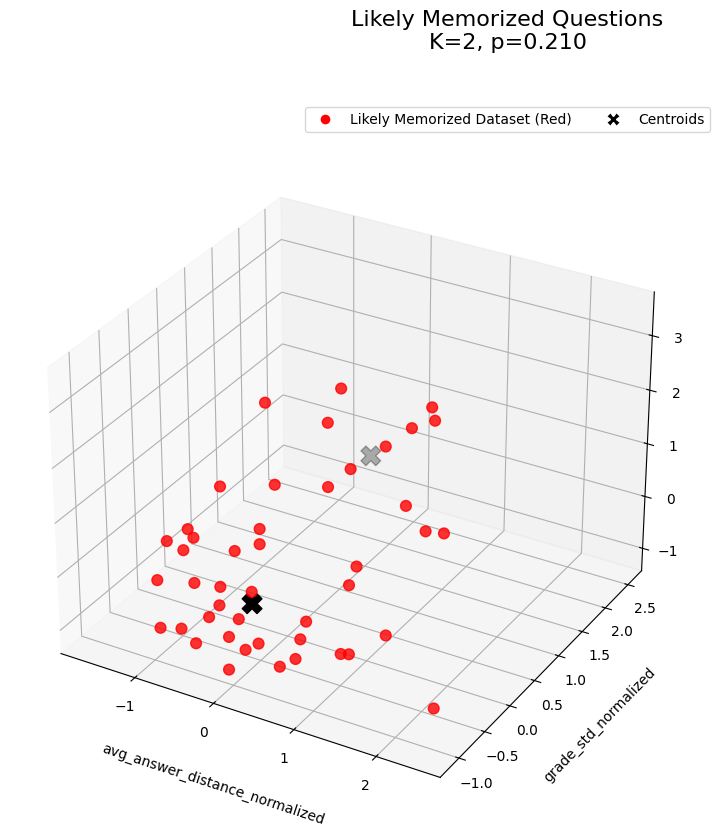

Validating significance for Combined Questions...
------------------------------
RESULTS FOR: Combined Questions
Optimal K (Silhouette): 2
Silhouette Score: 0.4889
SigClust p-value: 0.0100
Status: STATISTICALLY SIGNIFICANT clusters found.
------------------------------


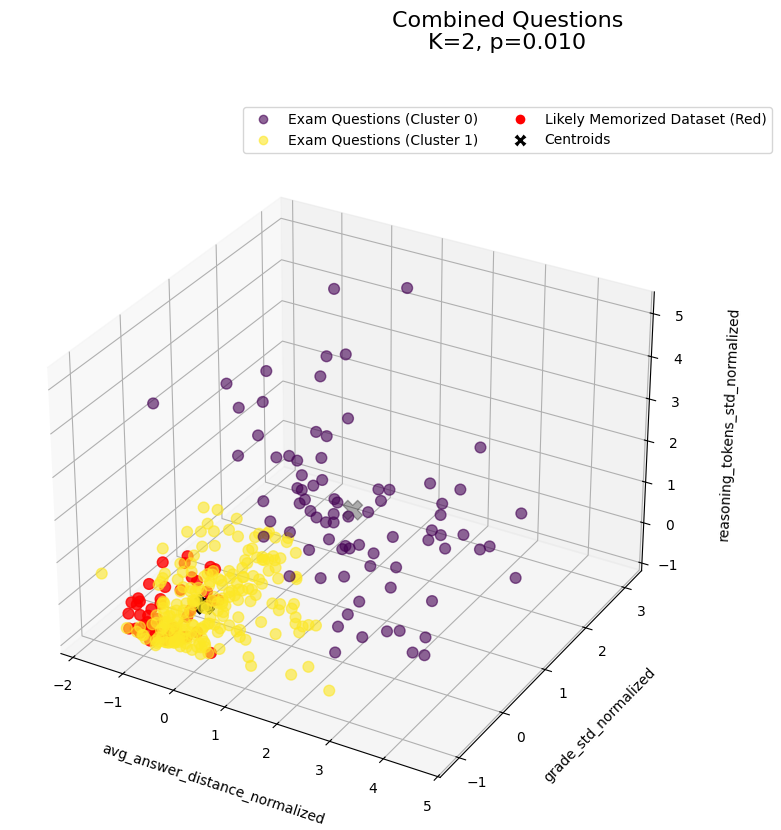

In [ ]:
from scipy.stats import multivariate_normal

def run_sigclust_validation(X, optimal_k, n_sim=100):
    """
    Validates if the chosen K is statistically significant 
    compared to a single Gaussian distribution (SigClust logic).
    """
    def get_ci(data, labels):
        tss = np.sum((data - np.mean(data, axis=0))**2)
        wss = 0
        for i in np.unique(labels):
            cluster_points = data[labels == i]
            wss += np.sum((cluster_points - np.mean(cluster_points, axis=0))**2)
        return wss / tss

    # 1. Observed Cluster Index
    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10).fit(X)
    obs_ci = get_ci(X, kmeans.labels_)

    # 2. Simulate Null Hypothesis (Single Multivariate Normal)
    mean = np.mean(X, axis=0)
    cov = np.cov(X, rowvar=False)
    
    null_cis = []
    for _ in range(n_sim):
        # Sample from a single distribution based on your real data's shape/cov
        null_data = np.random.multivariate_normal(mean, cov, size=X.shape[0])
        null_km = KMeans(n_clusters=optimal_k, n_init=1).fit(null_data)
        null_cis.append(get_ci(null_data, null_km.labels_))

    # 3. Calculate p-value
    p_value = np.sum(np.array(null_cis) <= obs_ci) / n_sim
    return obs_ci, p_value

def plot_kmeans_clusters(df, features, dataset_name):
    X = df[features].dropna().values
    
    silhouette_scores = []
    K_range = range(2, 6) 
    for K in K_range:
        kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(X)
        silhouette_scores.append(silhouette_score(X, cluster_labels))
    
    optimal_K = K_range[np.argmax(silhouette_scores)]
    max_sil = max(silhouette_scores)
    
    print(f"Validating significance for {dataset_name}...")
    obs_ci, p_value = run_sigclust_validation(X, optimal_K)
    
    print("-" * 30)
    print(f"RESULTS FOR: {dataset_name}")
    print(f"Optimal K (Silhouette): {optimal_K}")
    print(f"Silhouette Score: {max_sil:.4f}")
    print(f"SigClust p-value: {p_value:.4f}")
    
    if p_value < 0.05:
        print("Status: STATISTICALLY SIGNIFICANT clusters found.")
    else:
        print("Status: NOT SIGNIFICANT. Data may be a single distribution.")
    print("-" * 30)

    kmeans_optimal = KMeans(n_clusters=optimal_K, random_state=42, n_init=10)
    df['cluster'] = kmeans_optimal.fit_predict(X)
    
    # 1. MASSIVE WIDESCREEN CANVAS
    fig = plt.figure(figsize=(16, 9))
    
    # 2. FORCEFUL LAYOUT: Restrict graph to bottom-left 70% width
    ax = fig.add_axes([0.05, 0.05, 0.70, 0.75], projection='3d')
    
    source_col = 'dataset' if 'dataset' in df.columns else 'source'
    exams_mask = df[source_col] == 'exams_df'
    non_exams_mask = df[source_col] != 'exams_df'
    
    scatter_exams = None
    if exams_mask.any():
        scatter_exams = ax.scatter(df.loc[exams_mask, features[0]], 
                                   df.loc[exams_mask, features[1]], 
                                   df.loc[exams_mask, features[2]], 
                                   c=df.loc[exams_mask, 'cluster'], 
                                   cmap='viridis', s=60, alpha=0.6)
                                   
    if non_exams_mask.any():
        ax.scatter(df.loc[non_exams_mask, features[0]], 
                   df.loc[non_exams_mask, features[1]], 
                   df.loc[non_exams_mask, features[2]], 
                   c='red', s=60, alpha=0.8)
    
    centers = kmeans_optimal.cluster_centers_
    ax.scatter(centers[:, 0], centers[:, 1], centers[:, 2], c='black', marker='X', s=200)
    
    # Set all axis labels with padding
    ax.set_xlabel(features[0], labelpad=15)
    ax.set_ylabel(features[1], labelpad=15)
    ax.set_zlabel(features[2], labelpad=15) 
    
    # 3. STRICT LEGEND ORDERING
    handles, labels = [], []
    
    # A. Clusters first
    if scatter_exams is not None:
        cluster_handles, cluster_labels = scatter_exams.legend_elements()
        for h, l in zip(cluster_handles, cluster_labels):
            clean_label = l.replace('$\\mathdefault{', '').replace('}$', '')
            handles.append(h)
            labels.append(f"Exam Questions (Cluster {clean_label})")
            
    # B. Red dataset second
    if non_exams_mask.any():
        handles.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8))
        labels.append("Likely Memorized Dataset (Red)")
            
    # C. Centroids third
    handles.append(Line2D([0], [0], marker='X', color='w', markerfacecolor='black', markersize=10))
    labels.append("Centroids")
    
    # 4. PERFECT TOP STACKING
    fig.suptitle(f'{dataset_name}\nK={optimal_K}, p={p_value:.3f}', y=0.95, fontsize=16)
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.85), ncol=2)
    
    plt.show()

    return centers
# Run as before
features = ['avg_answer_distance_normalized', 'grade_std_normalized', 'reasoning_tokens_std_normalized']
# (Assuming your dfs are defined and normalized)
likely_memorized_clusters = plot_kmeans_clusters(df_likely_memorized, features, "Likely Memorized Questions")
combined_clusters = plot_kmeans_clusters(combined_df, features, "Combined Questions")

In [10]:
# print zipped centers sorted by avg_answer_distance_normalized - for likely memorized, combined
print("Cluster centers sorted by avg_answer_distance_normalized for likely memorized questions:")
for i, center in enumerate(likely_memorized_clusters):
    print(f"Cluster {i}: {center}")

print("\nCluster centers sorted by avg_answer_distance_normalized for combined questions:")
for i, center in enumerate(combined_clusters):
    print(f"Cluster {i}: {center}")

Cluster centers sorted by avg_answer_distance_normalized for likely memorized questions:
Cluster 0: [-0.11783179 -0.47514891 -0.44088851]
Cluster 1: [0.29004747 1.16959732 1.08526402]

Cluster centers sorted by avg_answer_distance_normalized for combined questions:
Cluster 0: [1.05078091 1.32049356 0.85398712]
Cluster 1: [-0.32610442 -0.40980835 -0.26503049]


In [11]:
# # use DBSCAN to cluster both datasets using the same features as above. use a 3-D scatter plot to visualize the clusters and color each cluster differently. print the number of clusters found by DBSCAN for each dataset.
# from sklearn.cluster import DBSCAN
# def plot_dbscan_clusters(df, features, dataset_name):
#     X = df[features].dropna()
#     dbscan = DBSCAN(eps=0.5, min_samples=5)
#     df['cluster'] = dbscan.fit_predict(X)
    
#     n_clusters = len(set(df['cluster'])) - (1 if -1 in df['cluster'] else 0)
#     print(f"Number of clusters found by DBSCAN for {dataset_name}: {n_clusters}")
    
#     fig = plt.figure(figsize=(10, 8))
#     ax = fig.add_subplot(111, projection='3d')
#     scatter = ax.scatter(df[features[0]], df[features[1]], df[features[2]], c=df['cluster'], cmap='viridis', s=100)
#     ax.set_title(f'DBSCAN Clusters for {dataset_name}')
#     ax.set_xlabel(features[0])
#     ax.set_ylabel(features[1])
#     ax.set_zlabel(features[2])
#     plt.show()
# plot_dbscan_clusters(df_likely_memorized, features, "Likely Memorized Questions")
# plot_dbscan_clusters(df_exam_questions, features, "Exam Questions")

### Calculating Strength of Clustering for each Question

In [43]:
# 1. Isolate the data for Cluster 1
cluster_1_mask = combined_df['cluster'] == 1
cluster_1_data = combined_df.loc[cluster_1_mask, features].values

# 2. Extract centroids (assumes index 0 is Cluster 0, index 1 is Cluster 1)
centroid_0 = combined_clusters[0]
centroid_1 = combined_clusters[1]

# 3. Calculate L2 distances to both centroids
# np.linalg.norm(axis=1) computes the Euclidean distance for each row
dist_to_0 = np.linalg.norm(cluster_1_data - centroid_0, axis=1)
dist_to_1 = np.linalg.norm(cluster_1_data - centroid_1, axis=1)

# 4. Calculate the ratio (Distance to 1 / Distance to 0)
# A ratio near 0 means the point is very close to its own center.
# A ratio near 1 means the point is equidistant from both (on the boundary).
distance_ratios = pd.Series(dist_to_1 / dist_to_0, index=combined_df.index[cluster_1_mask])

# Displaying summary statistics
print("Distance Ratio Summary (Dist to C1 / Dist to C0):")
print(distance_ratios.describe())

Distance Ratio Summary (Dist to C1 / Dist to C0):
count    261.000000
mean       0.367037
std        0.229164
min        0.066941
25%        0.212184
50%        0.276191
75%        0.448102
max        0.983809
dtype: float64


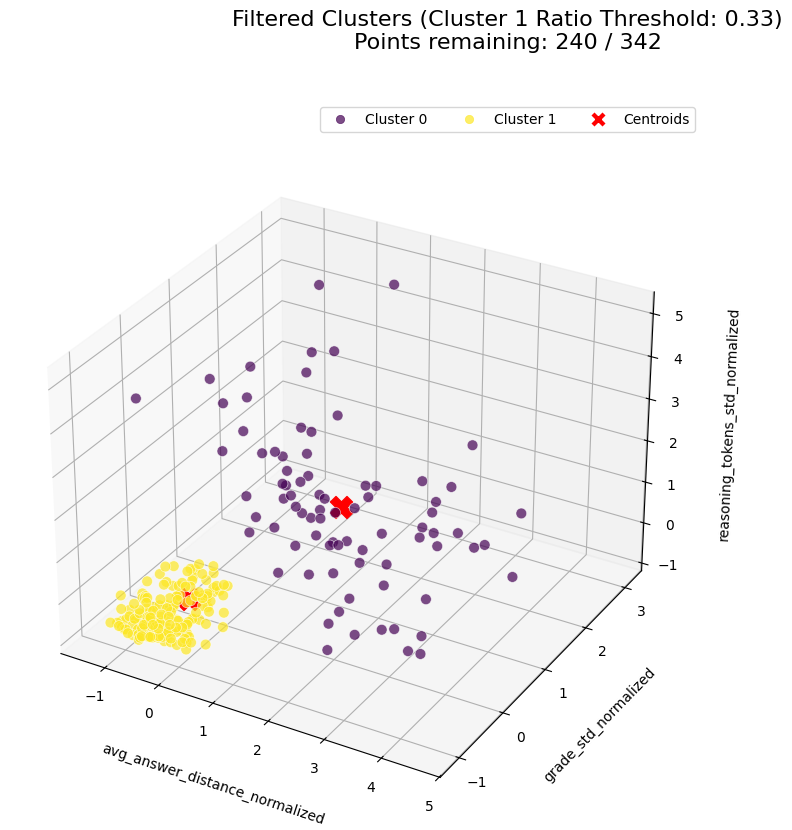

In [44]:
distance_ratio_threshold = 0.33

# def plot_significant_combined_clusters(df, features, combined_clusters, distance_ratios, threshold=0.5):
#     """
#     Plots:
#     1. All points from Cluster 0.
#     2. Only Cluster 1 points where the distance ratio is <= threshold.
#     """
#     # Define the mask:
#     # Keep if (Cluster is 0) OR (Cluster is 1 AND ratio is low)
#     # Note: distance_ratios only contains indices for Cluster 1, so we use .reindex
#     valid_c1_indices = distance_ratios[distance_ratios <= threshold].index
#     mask = (df['cluster'] == 0) | (df.index.isin(valid_c1_indices))
    
#     filtered_df = df[mask].copy()
    
#     # Setup Plot
#     fig = plt.figure(figsize=(12, 9))
#     ax = fig.add_subplot(111, projection='3d')
    
#     # Plotting
#     # Color by the original cluster ID to see the two groups
#     scatter = ax.scatter(
#         filtered_df[features[0]], 
#         filtered_df[features[1]], 
#         filtered_df[features[2]], 
#         c=filtered_df['cluster'], 
#         cmap='viridis', 
#         s=60, 
#         alpha=0.7,
#         edgecolors='w',
#         linewidth=0.5
#     )
    
#     # Plot Centroids
#     centers = np.array(combined_clusters)
#     ax.scatter(centers[:, 0], centers[:, 1], centers[:, 2], 
#                c='red', marker='X', s=250, label='Centroids', depthshade=False)

#     # Labeling
#     ax.set_title(f'Filtered Clusters (Cluster 1 Ratio Threshold: {threshold})\n'
#                  f'Points remaining: {len(filtered_df)} / {len(df)}')
#     ax.set_xlabel(features[0])
#     ax.set_ylabel(features[1])
#     ax.set_zlabel(features[2])
    
#     # Add a legend for the clusters
#     legend1 = ax.legend(*scatter.legend_elements(), loc="upper right", title="Clusters")
#     ax.add_artist(legend1)
    
#     plt.show()

def plot_significant_combined_clusters(df, features, combined_clusters, distance_ratios, threshold=0.5):
    """
    Plots:
    1. All points from Cluster 0.
    2. Only Cluster 1 points where the distance ratio is <= threshold.
    """
    # Define the mask:
    # Keep if (Cluster is 0) OR (Cluster is 1 AND ratio is low)
    # Note: distance_ratios only contains indices for Cluster 1, so we use .reindex
    valid_c1_indices = distance_ratios[distance_ratios <= threshold].index
    mask = (df['cluster'] == 0) | (df.index.isin(valid_c1_indices))
    
    filtered_df = df[mask].copy()
    
    # 1. MASSIVE WIDESCREEN CANVAS
    fig = plt.figure(figsize=(16, 9))
    
    # 2. FORCEFUL LAYOUT: Restrict graph to bottom-left 70% width
    # This leaves empty space on the right so the Z-axis doesn't get cut off
    ax = fig.add_axes([0.05, 0.05, 0.70, 0.75], projection='3d')
    
    # Plotting
    # Color by the original cluster ID to see the two groups
    scatter = ax.scatter(
        filtered_df[features[0]], 
        filtered_df[features[1]], 
        filtered_df[features[2]], 
        c=filtered_df['cluster'], 
        cmap='viridis', 
        s=60, 
        alpha=0.7,
        edgecolors='w',
        linewidth=0.5
    )
    
    # Plot Centroids
    centers = np.array(combined_clusters)
    ax.scatter(centers[:, 0], centers[:, 1], centers[:, 2], 
               c='red', marker='X', s=250, label='Centroids', depthshade=False)

    # 3. LABELING WITH PADDING
    ax.set_xlabel(features[0], labelpad=15)
    ax.set_ylabel(features[1], labelpad=15)
    ax.set_zlabel(features[2], labelpad=15)
    
    # 4. UNIFIED LEGEND (Clusters + Centroids)
    handles, labels = scatter.legend_elements()
    
    # Clean up math formatting in default scatter legend labels
    clean_labels = ["Cluster " + l.replace('$\\mathdefault{', '').replace('}$', '') for l in labels]
    
    # Append the Centroid marker to the handles/labels lists
    handles.append(Line2D([0], [0], marker='X', color='w', markerfacecolor='red', markersize=12))
    clean_labels.append("Centroids")
    
    # 5. PERFECT TOP STACKING
    # Title placed high up
    fig.suptitle(f'Filtered Clusters (Cluster 1 Ratio Threshold: {threshold})\n'
                 f'Points remaining: {len(filtered_df)} / {len(df)}', 
                 y=0.95, fontsize=16)
    
    # Unified legend placed right below the title
    fig.legend(handles, clean_labels, loc='upper center', bbox_to_anchor=(0.5, 0.85), ncol=len(clean_labels))
    
    plt.show()

# Execution
plot_significant_combined_clusters(combined_df, features, combined_clusters, distance_ratios, threshold=distance_ratio_threshold)

In [14]:
# 1. Filter for the target sources
target_sources = ['gpt', 'michal and amir']
filtered_sources_df = combined_df[combined_df['source'].isin(target_sources)].copy()

# 2. Attach the distance ratios to the dataframe
# We use .reindex to ensure the indices match correctly
filtered_sources_df['dist_ratio'] = distance_ratios

# 3. Display Cluster & Original Cluster counts
print(f"--- Cluster Mapping for {target_sources} ---")
mapping = filtered_sources_df.groupby(['source', 'cluster', 'original_cluster']).size().unstack(fill_value=0)
display(mapping)

# 4. Display Distance Ratio Stats per Source
print(f"\n--- Distance Ratio Stats (Cluster 1 Membership Strength) ---")
# This only applies to points in Cluster 1 since ratios were calculated for C1
ratio_stats = filtered_sources_df[filtered_sources_df['cluster'] == 1].groupby('source')['dist_ratio'].describe()
display(ratio_stats)

# print the amount of questions from each source below and above the distance ratio threshold for cluster 1
print(f"\n--- Source Counts by Distance Ratio Threshold (Cluster 1) ---")
for source in target_sources:
    source_mask = (filtered_sources_df['source'] == source) & (filtered_sources_df['cluster'] == 1)
    below_threshold = (filtered_sources_df['dist_ratio'] <= distance_ratio_threshold) & source_mask
    above_threshold = (filtered_sources_df['dist_ratio'] > distance_ratio_threshold) & source_mask
    print(f"{source}: {below_threshold.sum()} below threshold, {above_threshold.sum()} above threshold")

--- Cluster Mapping for ['gpt', 'michal and amir'] ---


,original_cluster,0,1
source,cluster,,
gpt,1,21,12
michal and amir,1,11,1



--- Distance Ratio Stats (Cluster 1 Membership Strength) ---


,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
gpt,33.0,0.278551,0.103291,0.066941,0.219728,0.281534,0.346566,0.547179
michal and amir,12.0,0.260250,0.075835,0.100534,0.211910,0.263768,0.302961,0.380012



--- Source Counts by Distance Ratio Threshold (Cluster 1) ---
gpt: 22 below threshold, 11 above threshold
michal and amir: 10 below threshold, 2 above threshold


In [15]:
# export the following columns to excel in the input directory: 
# 'id', 'dataset', 'source', 'cluster' (rename to likely_memorized), 'avg_answer_distance', 'grade_std', 'reasoning_tokens_std', 'dist_ratio', 
# 'year', 'semester', 'moed', 'question', 'section', 'points', 'question_hebrew', 'solution_hebrew', 'avg_score', 'std_score',
# 'max_score', 'avg_score_norm', 'std_score_norm', 'question_english', 'solution_english', 'subject_labels', 'task_type_labels', 'custom_id'
combined_df['dist_ratio'] = distance_ratios.reindex(combined_df.index)  # Ensure correct alignment of distance ratios
export_columns = [
    'custom_id', 'id', 'dataset', 'source', 'cluster', 'avg_answer_distance', 'grade_std', 'grade_mean', 'reasoning_tokens_std', 'reasoning_tokens_mean', 'dist_ratio',
    'year', 'semester', 'moed', 'question', 'section', 'points', 'question_hebrew', 'solution_hebrew', 'avg_score', 'std_score',
    'max_score', 'avg_score_norm', 'std_score_norm', 'question_english', 'solution_english', 'subject_labels', 'task_type_labels'
]
export_df = combined_df[export_columns].copy()
export_df = export_df.rename(columns={'cluster': 'likely_memorized_classification'})
export_path = INPUT_DIR / "combined_questions_with_classification.xlsx"
export_df.to_excel(export_path, index=False)
print(f"Exported combined questions with classification to: {export_path}")

Exported combined questions with classification to: c:\projects\LLMsForEducation\inputs\combined_questions_with_classification.xlsx


## Bayesian Classification - DID NOT WORK

In [33]:
combined_df['memorization_label'] = combined_df['dataset'].apply(lambda x: 'likely_memorized' if x == 'likely_memorized_df' else 'uncertain')
print(combined_df.columns)

Index(['id', 'question_english', 'source', 'solution_english',
       'reasoning_tokens_mean', 'reasoning_tokens_std', 'reasoning_tokens_min',
       'reasoning_tokens_max', 'reasoning_tokens_median',
       'log_reasoning_tokens_mean', 'log_reasoning_tokens_std',
       'log_reasoning_tokens_min', 'log_reasoning_tokens_max',
       'log_reasoning_tokens_median', 'grade_mean', 'grade_std', 'grade_min',
       'grade_max', 'grade_median', 'reasoning_tokens_mean_normalized',
       'reasoning_tokens_std_normalized', 'reasoning_tokens_min_normalized',
       'reasoning_tokens_max_normalized', 'reasoning_tokens_median_normalized',
       'log_reasoning_tokens_mean_normalized',
       'log_reasoning_tokens_std_normalized',
       'log_reasoning_tokens_min_normalized',
       'log_reasoning_tokens_max_normalized',
       'log_reasoning_tokens_median_normalized', 'grade_mean_normalized',
       'grade_std_normalized', 'grade_min_normalized', 'grade_max_normalized',
       'grade_median_normal

In [52]:
# PU learning (Positive–Unlabeled) over XGBoost using Elkan & Noto wrapper.
# Assumes:
#   combined_df['memorization_label'] in {'likely_memorized', 'uncertain'}
#   positives: 'likely_memorized'  -> s=1
#   unlabeled: 'uncertain'         -> s=0
#
# Output:
#   combined_df['pu_p_memorized']  ~= P(y=1 | x)
#   combined_df['pu_score_s1']     ~= P(s=1 | x) (selection probability)
#   combined_df['pu_c']            estimated c = P(s=1 | y=1)
FEATURES = [
    "avg_answer_distance",
    # "reasoning_tokens_mean",
    "reasoning_tokens_std",
    # "log_reasoning_tokens_mean",
    # "log_reasoning_tokens_std",
    "grade_mean",
    "grade_std",
]
df = combined_df[(combined_df['source'] != 'gpt') | (combined_df['cluster'] == 0)].copy()

# s-label: 1 for known positives, 0 for unlabeled
df["s_label"] = (df["memorization_label"] == "likely_memorized").astype(int)
display(df[["memorization_label", "s_label"]].value_counts())

# clean
df_model = df[FEATURES + ["s_label"]].replace([np.inf, -np.inf], np.nan).dropna().copy()
X = df_model[FEATURES].to_numpy()
s = df_model["s_label"].to_numpy()

X_train, X_val, s_train, s_val = train_test_split(
    X, s, test_size=0.2, random_state=42, stratify=s
)

# Base XGBoost config
xgb_params = dict(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=15,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    min_child_weight=1,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)

# -----------------------
# 1) PU model: gives P(y=1|x)
# -----------------------
base_for_pu = XGBClassifier(**xgb_params)

pu = ElkanotoPuClassifier(
    estimator=base_for_pu,
    hold_out_ratio=0.2
)

pu.fit(X_train, s_train)

# PU-corrected probability P(y=1|x)
# (ElkanotoPuClassifier provides predict_proba in pulearn; this is what we want.)
p_y1_all = pu.predict_proba(X)[:, 1]
p_y1_val = pu.predict_proba(X_val)[:, 1]

# Estimate c if available (varies by version)
c_hat = getattr(pu, "c_", None)

# -----------------------
# 2) Separate plain model on s-labels (sanity checks only)
# -----------------------
plain_s_model = XGBClassifier(**xgb_params)
plain_s_model.fit(X_train, s_train)

p_s1_val = plain_s_model.predict_proba(X_val)[:, 1]
p_s1_all = plain_s_model.predict_proba(X)[:, 1]

print("Sanity check vs s-labels (labeled positive vs unlabeled):")
print("  ROC-AUC:", roc_auc_score(s_val, p_s1_val))
print("  PR-AUC :", average_precision_score(s_val, p_s1_val))
if c_hat is not None:
    print("Estimated c = P(s=1 | y=1):", float(c_hat))

# -----------------------
# 3) Write back to combined_df
# -----------------------
combined_df = combined_df.copy()
combined_df.loc[df_model.index, "pu_p_memorized"] = p_y1_all          # PU probability
combined_df.loc[df_model.index, "raw_p_s1"] = p_s1_all               # selection score (sanity)
if c_hat is not None:
    combined_df.loc[df_model.index, "pu_c"] = float(c_hat)

# Optional: categorical bucket
def to_bucket(p):
    if pd.isna(p):
        return np.nan
    if p < 0.33:
        return "low"
    if p < 0.66:
        return "medium"
    return "high"

combined_df["memorization_likelihood_bucket"] = combined_df["pu_p_memorized"].apply(to_bucket)

display(combined_df["memorization_likelihood_bucket"].value_counts(dropna=False))

memorization_label  s_label
uncertain           0          297
likely_memorized    1           33
Name: count, dtype: int64

Sanity check vs s-labels (labeled positive vs unlabeled):
  ROC-AUC: 0.900726392251816
  PR-AUC : 0.6179723502304146


memorization_likelihood_bucket
low       292
high       43
medium      7
Name: count, dtype: int64

In [53]:
# Get counts excluding 'gpt' source
cluster_counts = (
    combined_df[(combined_df['source'] != 'gpt') | (combined_df['cluster'] == 0)]
    [['memorization_likelihood_bucket', 'dataset', 'cluster']]
    .value_counts(dropna=False)
    .sort_index()
)

# Calculate percentages within each cluster
cluster_percentages = (
    cluster_counts
    .groupby(level=2)  # Group by cluster (level 2)
    .apply(lambda x: 100 * x / float(x.sum()))
)

# Drop the duplicate cluster level created by groupby
cluster_percentages.index = cluster_percentages.index.droplevel(0)

# Sort both by the original order (no reordering needed)
cluster_counts = cluster_counts.sort_index()
cluster_percentages = cluster_percentages.sort_index()

display(cluster_counts)
display(cluster_percentages)


memorization_likelihood_bucket  dataset              cluster
high                            exams_df             1            8
                                likely_memorized_df  0           26
                                                     1            1
low                             exams_df             0           70
                                                     1          194
                                                     2           23
                                likely_memorized_df  0            2
medium                          exams_df             1            2
                                likely_memorized_df  0            4
Name: count, dtype: int64

memorization_likelihood_bucket  dataset              cluster
high                            exams_df             1            3.902439
                                likely_memorized_df  0           25.490196
                                                     1            0.487805
low                             exams_df             0           68.627451
                                                     1           94.634146
                                                     2          100.000000
                                likely_memorized_df  0            1.960784
medium                          exams_df             1            0.975610
                                likely_memorized_df  0            3.921569
Name: count, dtype: float64

In [15]:
# interpret classifier decision boundaries using SHAP or similar (not implemented here, but would be a next step to understand feature importance and how the model is making predictions)
